In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from pathlib import Path
import re
# Auto reload matplotlib in Jupyter
%matplotlib inline

# Path relative to this notebook
residuals_path = Path('..') / 'results' / 'independence' / 'residuals.csv'
df = pd.read_csv(residuals_path)

# Preview
df.head()


,dataset,ka,kb,hgr_x_epshat,acc,f_type,noise_type,is_independent,is_noiseless
0,D_quintic_noiseless_logistic_normal_91,3,1,1.000000,0,quintic_noiseless,logistic,False,True
1,D_random_pair_logistic_0.4_normal_91,3,1,0.067762,1,random_pair,logistic,True,False
2,D_quintic_logistic_0.3_normal_91,3,1,0.697804,1,quintic,logistic,False,False
3,D_random_pair_logistic_0.4_normal_30,3,1,0.049970,1,random_pair,logistic,True,False
4,D_quintic_logistic_0.3_normal_30,3,1,0.964712,0,quintic,logistic,False,False


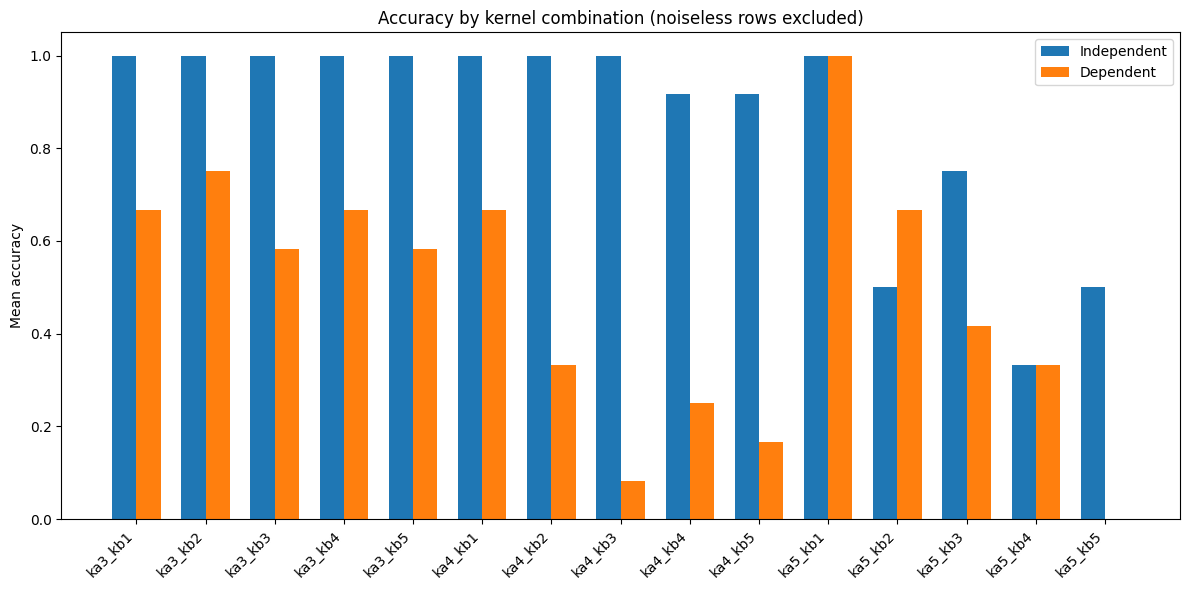

In [6]:

# --- Residual accuracy visualisation (fixed column names) ---
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
%matplotlib inline

# Load residuals
residuals_path = Path('..') / 'results' / 'independence' / 'residuals.csv'
df = pd.read_csv(residuals_path)

# 1. Filter out noiseless datasets
df_filtered = df[~df['is_noiseless']]

# 2. Group by kernel and independence flag
grouped = (
    df_filtered
      .groupby(['ka', 'kb', 'is_independent'])['acc']
      .mean()
      .unstack(fill_value=np.nan)
      .reindex(columns=[True, False])
)

# 3. Prepare labels
kernel_labels = [f'ka{ka}_kb{kb}' for ka, kb in grouped.index]

# 4. Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(kernel_labels))
width = 0.35

ax.bar(x - width/2, grouped[True], width, label='Independent')
ax.bar(x + width/2, grouped[False], width, label='Dependent')

ax.set_ylabel('Mean accuracy')
ax.set_title('Accuracy by kernel combination (noiseless rows excluded)')
ax.set_xticks(x)
ax.set_xticklabels(kernel_labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()



=== Kernel: good (ka=5, kb=1) ===


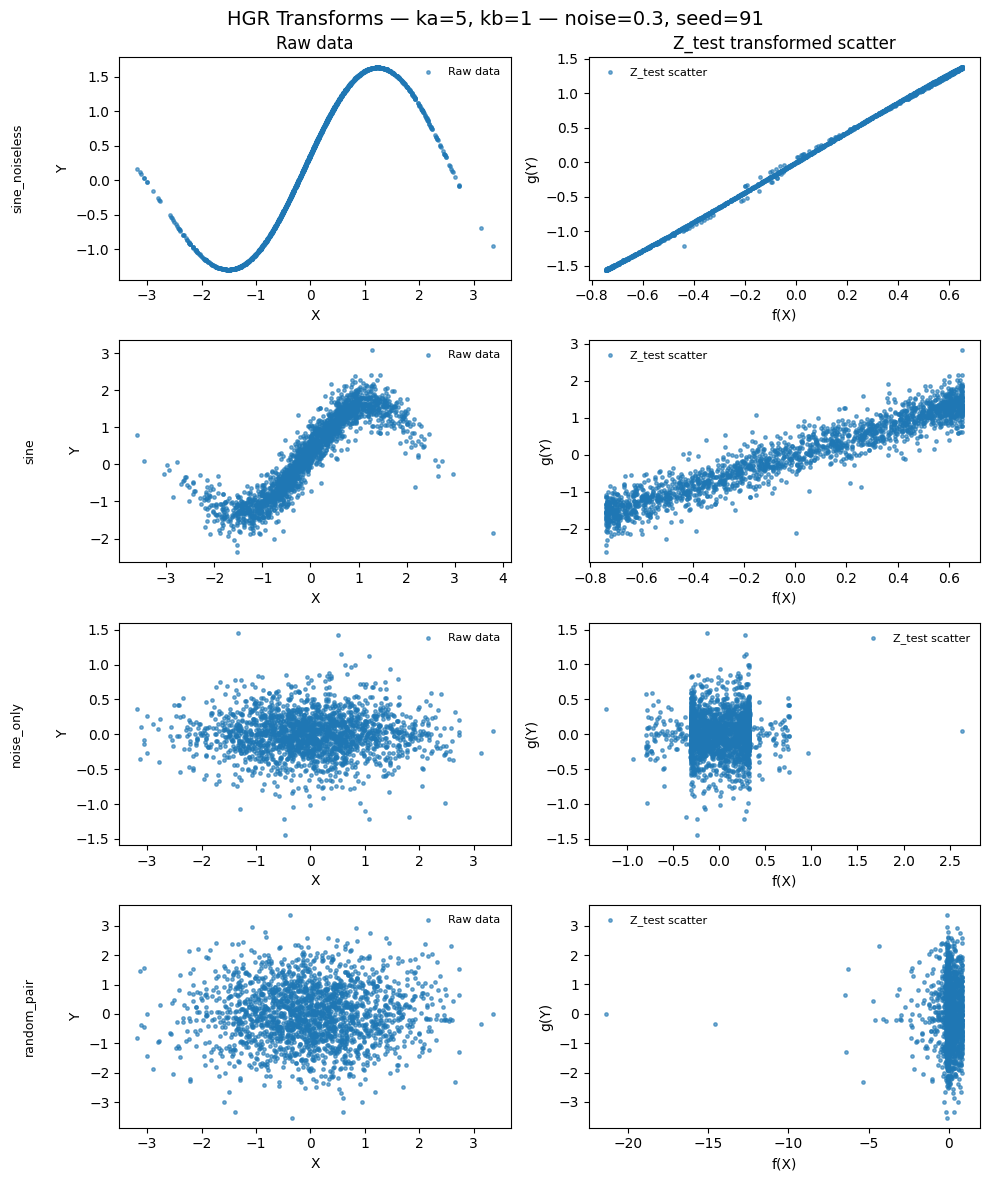


=== Kernel: underfit (ka=3, kb=1) ===


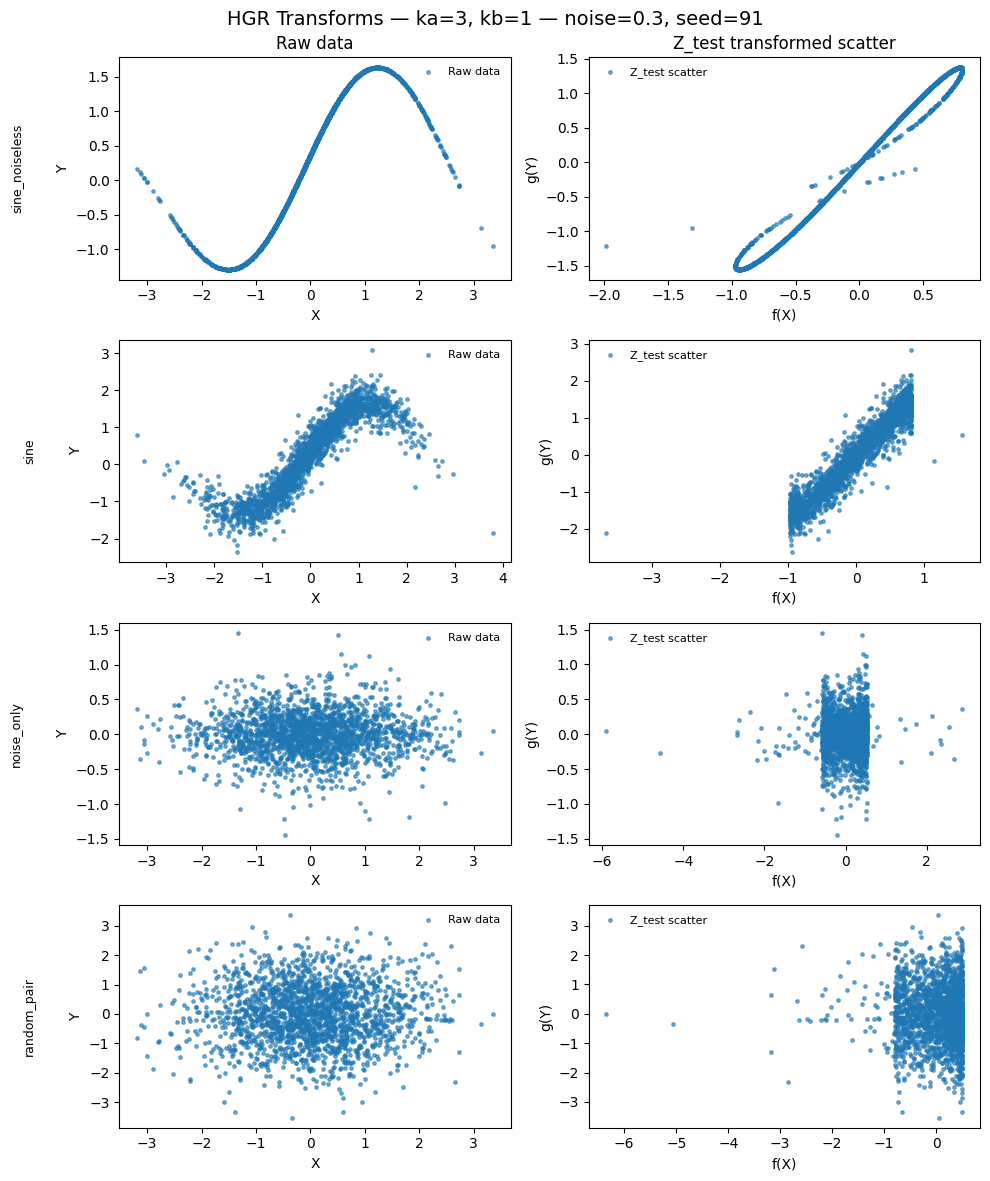


=== Kernel: overfit (ka=5, kb=4) ===


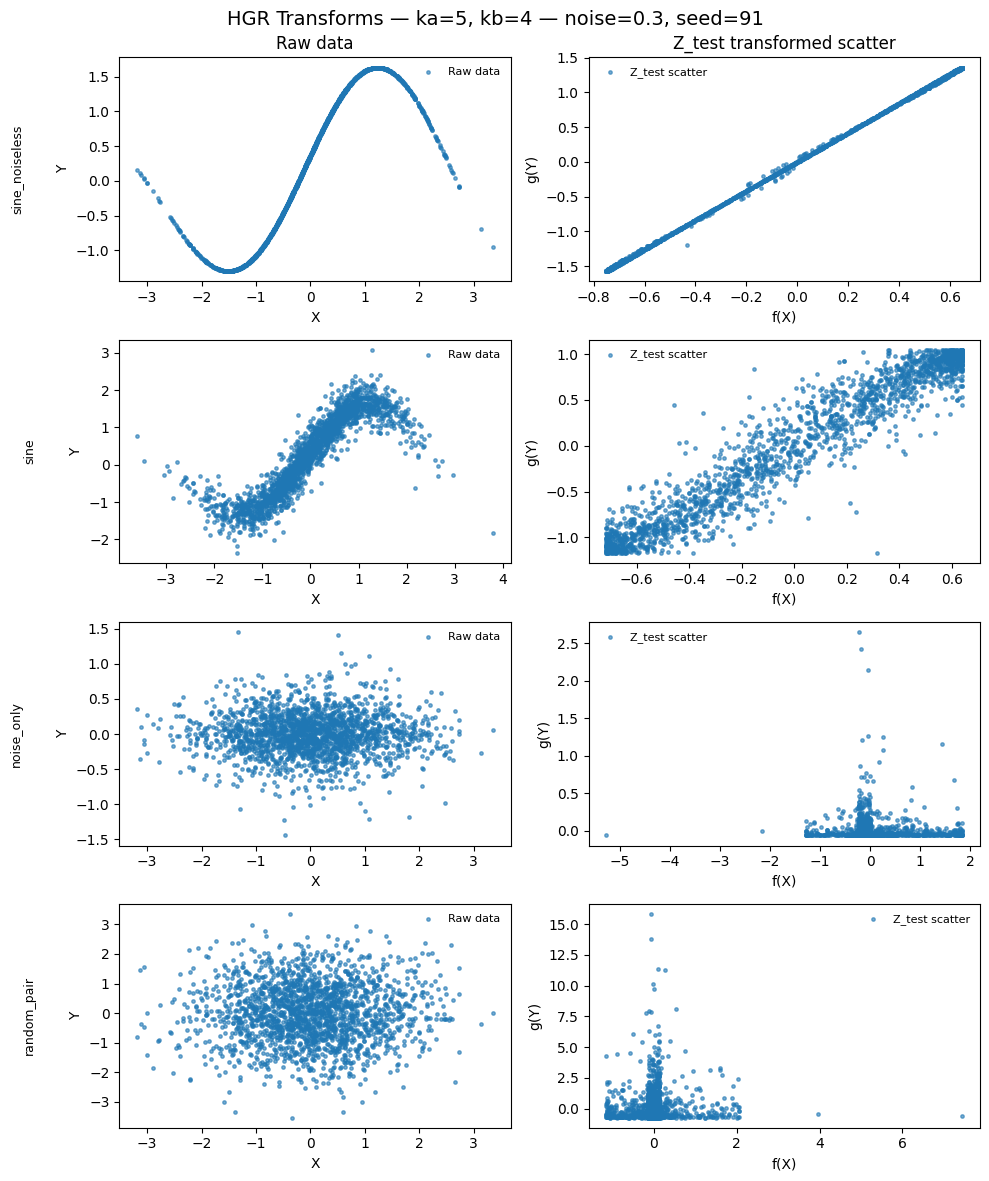

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
%matplotlib inline

ROOT_RESULTS = Path('..') / 'results' / 'hgr'
ROOT_DATA    = Path('..') / 'datasets'

NOISE_SCALE  = '0.3'
SEED         = '91'

DATASETS = [
    'sine_noiseless',
    'sine',
    'noise_only',
    'random_pair',
]

KERNELS = {
    'good': (5, 1),
    'underfit': (3, 1),
    'overfit': (5, 4),
}

def find_dataset_dir(kernel_dir: Path, ds_key: str) -> Path:
    if ds_key.endswith('noiseless'):
        regex = fr'D_.*{re.escape(ds_key)}.*_normal_{SEED}$'
    else:
        regex = fr'D_.*{re.escape(ds_key)}.*_logistic_{NOISE_SCALE}_normal_{SEED}$'
    
    pattern = re.compile(regex)
    for sub in kernel_dir.iterdir():
        if sub.is_dir() and pattern.match(sub.name):
            return sub
    raise FileNotFoundError(f'No directory for {ds_key} in {kernel_dir}')

def poly_eval(coeffs: np.ndarray, x: np.ndarray):
    return np.polyval(coeffs, x)

for label, (ka, kb) in KERNELS.items():
    kernel_dir = ROOT_RESULTS / f'ka{ka}_kb{kb}_numpy_dk'
    print(f"\n=== Kernel: {label} (ka={ka}, kb={kb}) ===")
    n_rows = len(DATASETS)
    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 3 * n_rows), squeeze=False)

    for row, ds_key in enumerate(DATASETS):
        try:
            ds_dir = find_dataset_dir(kernel_dir, ds_key)
        except FileNotFoundError as e:
            print(e)
            continue

        test_csv = ROOT_DATA / ds_dir.name / 'test.csv'
        if not test_csv.exists():
            print(f'test.csv not found for {ds_dir.name}')
            continue
        test_df = pd.read_csv(test_csv)
        X = test_df.iloc[:, 0].values
        Y = test_df.iloc[:, 1].values

        alpha = np.load(ds_dir / 'alpha.npy')
        beta = np.load(ds_dir / 'beta.npy')

        Z_test = np.load(ds_dir / 'Z_test.npy')
        fX = Z_test[:, 0]
        gY = Z_test[:, 1]

        # Raw plot
        ax_raw = axes[row, 0]
        ax_raw.scatter(X, Y, s=6, alpha=0.6, label='Raw data')
        if row == 0:
            ax_raw.set_title('Raw data')
        ax_raw.set_xlabel('X')
        ax_raw.set_ylabel('Y')
        ax_raw.legend(frameon=False, fontsize=8)

        # Transformed plot
        ax_tr = axes[row, 1]
        ax_tr.scatter(fX, gY, s=6, alpha=0.6, label='Z_test scatter')
        if row == 0:
            ax_tr.set_title('Z_test transformed scatter')
        ax_tr.set_xlabel('f(X)')
        ax_tr.set_ylabel('g(Y)')
        ax_tr.legend(frameon=False, fontsize=8)

        # Row label
        ax_raw.annotate(ds_key, xy=(0, 0.5), xytext=(-ax_raw.yaxis.labelpad - 20, 0),
                        xycoords=ax_raw.yaxis.label, textcoords='offset points',
                        ha='right', va='center', rotation=90, size=9)

    fig.subplots_adjust(top=0.94)
    fig.suptitle(f'HGR Transforms — ka={ka}, kb={kb} — noise={NOISE_SCALE}, seed={SEED}', fontsize=14)
    plt.tight_layout()
    plt.show()


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# Project folder roots
ROOT_RESULTS = Path("..") / "results"
ROOT_DATA    = Path("..") / "datasets"

def visualize_lingam_testset(dataset_name: str, kernel_tag: str = "ka5_kb1_numpy_dk"):
    """
    Visualize causal inference pipeline output on the TEST SET:
    - Original raw data (x, y)
    - HGR-transformed (u, v)
    - Residual scatter plots
    """

    # === Load raw test set ===
    df = pd.read_csv(ROOT_DATA / dataset_name / "test.csv")
    x = df["x"].values
    y = df["y"].values

    # === Load HGR output ===
    Z = np.load(ROOT_RESULTS / "hgr" / kernel_tag / dataset_name / "Z_test.npy")
    u, v = Z[:, 0], Z[:, 1]

    # === Load LiNGAM residuals & direction ===
    lingam_dir = ROOT_RESULTS / "lingam" / f"{kernel_tag}_direct" / dataset_name
    resid = np.load(lingam_dir / "residuals_test.npy")
    ordering = json.load(open(lingam_dir / "ordering.json"))
    acc = json.load(open(lingam_dir / "metrics.json"))["direction_acc"]

    # === Format inferred direction ===
    inferred_arrow = "u → v" if ordering == [0, 1] else "v → u"

    # === PLOTS ===
    fig, axs = plt.subplots(2, 2, figsize=(8, 5))  # smaller plot size

    axs[0, 0].scatter(x, y, alpha=0.4, s=10)
    axs[0, 0].set_title("Raw Test Data (x, y)")

    axs[0, 1].scatter(u, v, alpha=0.4, s=10)
    axs[0, 1].set_title("HGR Test (u, v)")

    axs[1, 0].scatter(u, resid[:, 1], alpha=0.4, s=10)
    axs[1, 0].set_title("Residual: v ~ u")

    axs[1, 1].scatter(v, resid[:, 0], alpha=0.4, s=10)
    axs[1, 1].set_title("Residual: u ~ v")

    fig.suptitle(f"{dataset_name} | {kernel_tag} | Inferred: {inferred_arrow}",
                 fontsize=12)
    plt.tight_layout()
    plt.show()


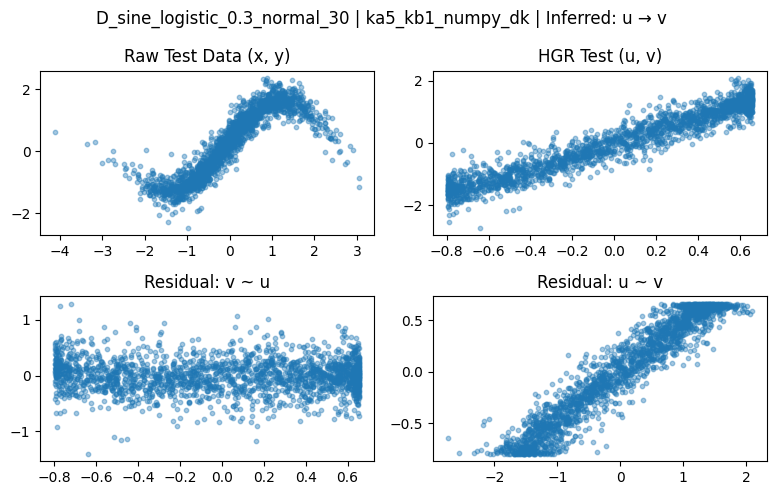

In [11]:
visualize_lingam_testset("D_sine_logistic_0.3_normal_30")


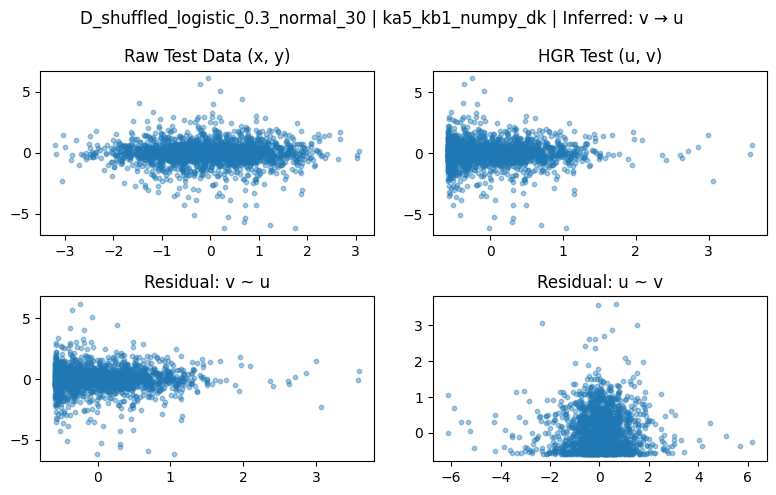

In [85]:
visualize_lingam_testset("D_shuffled_logistic_0.3_normal_30")


In [9]:
visualize_lingam_testset("D_sine_noiseless_logistic_normal_30")


NameError: name 'visualize_lingam_testset' is not defined

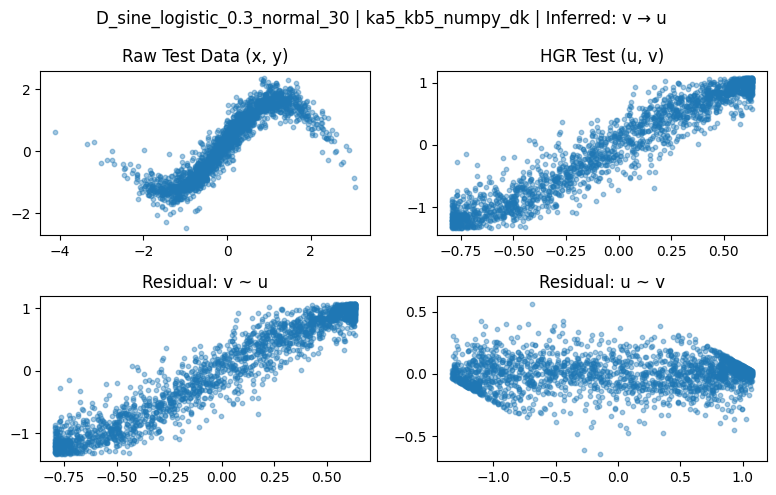

In [87]:

visualize_lingam_testset("D_sine_logistic_0.3_normal_30","ka5_kb5_numpy_dk")


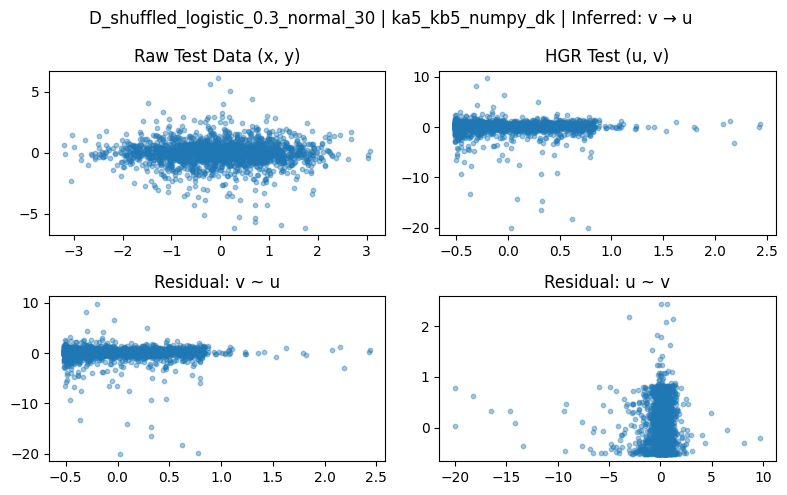

In [88]:
visualize_lingam_testset("D_shuffled_logistic_0.3_normal_30","ka5_kb5_numpy_dk")


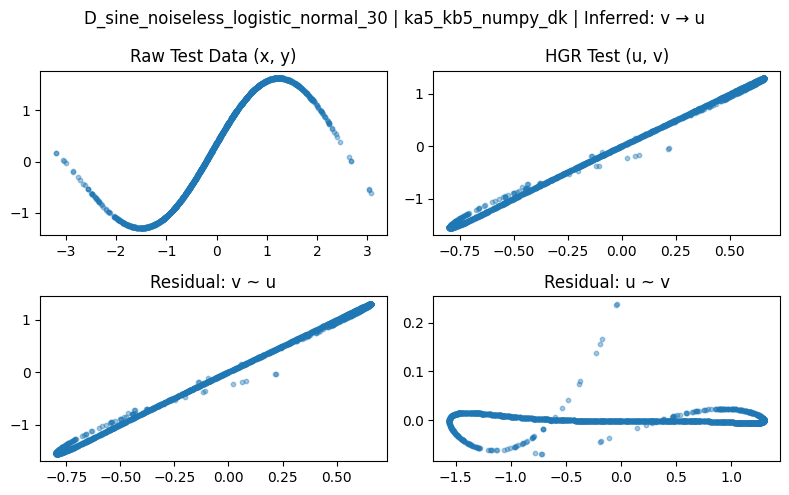

In [89]:
visualize_lingam_testset("D_sine_noiseless_logistic_normal_30","ka5_kb5_numpy_dk")


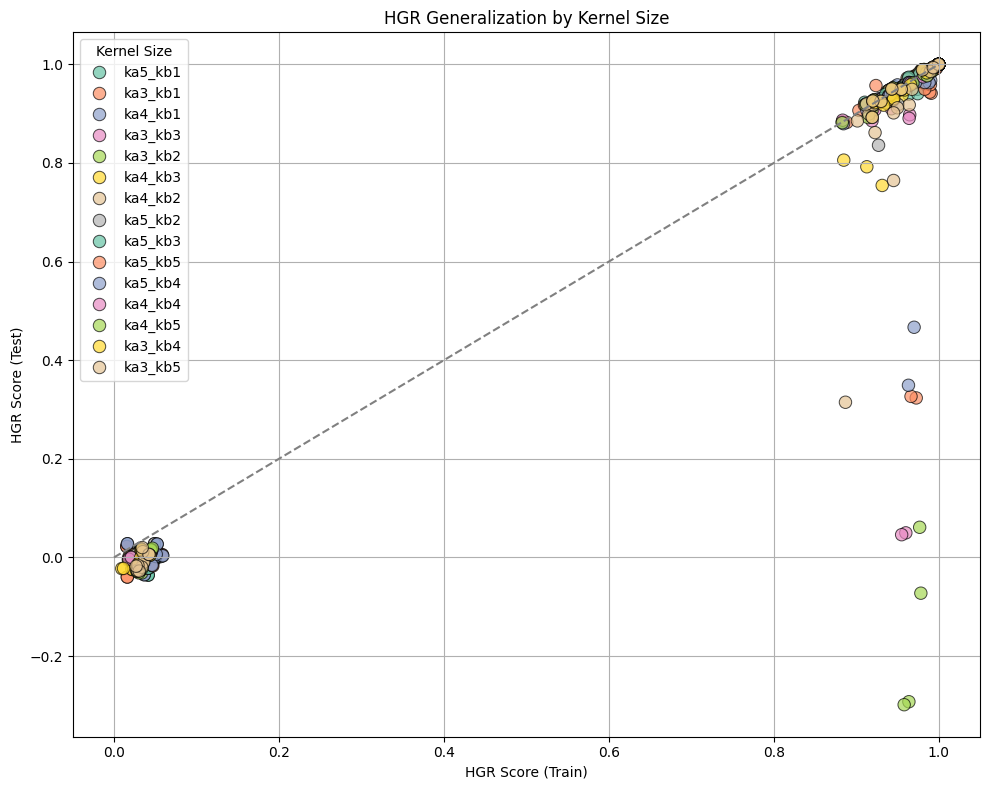

In [58]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ------------------------------------------------------------------------------
# Config paths
ROOT_HGR = Path("..") / "results" / "hgr"

# ------------------------------------------------------------------------------
# Collect HGR scores and kernel sizes
records = []

for kernel_dir in ROOT_HGR.glob("*"):
    if not kernel_dir.is_dir():
        continue

    for dataset_dir in kernel_dir.glob("*"):
        hgr_path = dataset_dir / "hgr.json"
        if not hgr_path.exists():
            continue

        try:
            with open(hgr_path) as f:
                data = json.load(f)

            if "rho_train" not in data or "rho_test" not in data:
                print(f"⚠️ Missing keys in: {dataset_dir.name} — skipped")
                continue

            kernel_a = data.get("algo_kwargs", {}).get("kernel_a", None)
            kernel_b = data.get("algo_kwargs", {}).get("kernel_b", None)

            records.append({
                "dataset": dataset_dir.name,
                "kernel_folder": kernel_dir.name,
                "rho_train": data["rho_train"],
                "rho_test": data["rho_test"],
                "kernel_a": kernel_a,
                "kernel_b": kernel_b,
            })

        except Exception as e:
            print(f"⚠️ Error reading {dataset_dir.name}: {e}")

# ------------------------------------------------------------------------------
# Convert to DataFrame and plot
hgr_df = pd.DataFrame.from_records(records)

if hgr_df.empty:
    print("❌ No valid HGR scores found.")
else:
    hgr_df["kernel_label"] = hgr_df.apply(lambda row: f"ka{row.kernel_a}_kb{row.kernel_b}", axis=1)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=hgr_df,
        x="rho_train",
        y="rho_test",
        hue="kernel_label",
        palette="Set2",
        s=80,
        edgecolor="black",
        alpha=0.7
    )

    plt.plot([0, 1], [0, 1], ls="--", color="gray")
    plt.xlabel("HGR Score (Train)")
    plt.ylabel("HGR Score (Test)")
    plt.title("HGR Generalization by Kernel Size")
    plt.grid(True)
    plt.legend(title="Kernel Size", loc="upper left")
    plt.tight_layout()
    plt.show()
